In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [86]:
lead=pd.read_csv('Leads.csv')
print(lead.shape)

(9240, 37)


In [87]:
lead['Converted'].mean()

np.float64(0.3853896103896104)

In [88]:
lead.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [89]:
# Converting all Select values to NaN.
# 'Select' is the default dropdown option the user never changed —
# it carries no information, so it is effectively a missing value

lead=lead.replace('Select', np.nan)

In [90]:
lead.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


# Checking for duplicate values

In [91]:
lead.duplicated().sum()

np.int64(0)

In [92]:
print(lead['Prospect ID'].duplicated().sum())
print(lead['Lead Number'].duplicated().sum())

0
0


In [93]:
lead.shape

(9240, 37)

## Drop data redundant columns

In [94]:
# Zero variance in columns, all have the same value

cols_to_drop= [
    'Magazine',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

lead= lead.drop(columns= cols_to_drop, errors='ignore')

print(lead.shape)



print(f"Shape of the dataframe after dropping columns: {lead.shape}")

(9240, 32)
Shape of the dataframe after dropping columns: (9240, 32)


In [95]:
# Almost same values with 99% similarity

cols_to_drop_more =[
    'Do Not Call',
    'What matters most to you in choosing a course',
    'Search',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations'
]

lead= lead.drop(columns= cols_to_drop_more, errors='ignore')

print(f"Shape of the dataframe after dropping additional columns: {lead.shape}")

Shape of the dataframe after dropping additional columns: (9240, 24)


In [96]:
lead.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137
Last Activity,103



1.  Dropping columns with very high missing values like
'How did you hear about X Education' (78.5%) and 'Lead Profile' (74.2%) since they are mostly empty. Imputing them would mean fabricating data for the majority of rows, so the model will not learn real patterns.

2.   The four Asymmetrique index/score columns (45.6% missing each) are also internally redundant and undocumented, so all four are dropped.

3. 'Lead Quality' (51.6% missing) is dropped for an additional reason: it is assigned by a sales employee after contacting the lead, so it would not be available at the time of prediction — keeping it would cause data leakage.



In [97]:
high_mising_cols= ['Asymmetrique Activity Index',
                       'Asymmetrique Profile Index',
                       'Asymmetrique Activity Score',
                       'Asymmetrique Profile Score',
                       'Lead Quality',
                       'Lead Profile',
                       'How did you hear about X Education']

lead= lead.drop(columns=high_mising_cols)
lead.shape

(9240, 17)


*  Country: 96% of non-null values are 'India' -> near-constant, no predictive value

*   City: 39.7% missing and dominated by Mumbai; X Education is an online business and City is not going add any significance

*  Tags: sales-team notes written DURING follow-up calls (e.g. 'Ringing',
'Will revert after reading the email')-> not available for a fresh lead -> data leakage

*  Occupation & Specialization: kept — genuine pre-contact info; missing values made an explicit 'Unknown' category since not filling the form may itself signal intent

In [98]:
# Drop low information geographicals and leakage prone sales notes


lead= lead.drop(columns=['City', 'Country', 'Tags'], errors='ignore')

# Keep but make missingness an explicit category

lead['What is your current occupation'] = lead['What is your current occupation'].fillna('Unknown')
lead['Specialization'] = lead['Specialization'].fillna('Unknown')


print(f"Shape of the dataset after droping the above columns: {lead.shape}")

Shape of the dataset after droping the above columns: (9240, 14)


Zero-variance columns carry no information by definition; >99%-constant columns can't separate converters from non-converters and would only add noise as dummies.

In [99]:
lead=lead.dropna() #dropping all rows with NaN values which will not affect the model

print(lead.isnull().sum().sum()) #Making sure there are no null value across the dataset and it is clean to proceed for further analysis

print(f" Final shape of the dataset: {lead.shape}")  # Checking the final size of the dataset after droping Nan Values

0
 Final shape of the dataset: (9074, 14)


In [100]:
lead['Converted'].mean()  # Sanity check to make sure the data cleaning is not going to affect the model critically, since our main concern is coversion rates and it seems to be the same unafffected by droping rows and colums

np.float64(0.3785541106458012)

EDA

##CALCULATING CONVERSION RATE

In [101]:
overall_conversion= lead['Converted'].mean()
print(f"Overall conversion rate: {overall_conversion*100:.1f}%")

Overall conversion rate: 37.9%


In [102]:
print(lead.groupby('Lead Origin').size())

Lead Origin
API                        3578
Landing Page Submission    4885
Lead Add Form               581
Lead Import                  30
dtype: int64


In [103]:
print(lead.groupby('Lead Origin')['Converted'].agg(['mean', 'count']))

                             mean  count
Lead Origin                             
API                      0.311627   3578
Landing Page Submission  0.361720   4885
Lead Add Form            0.936317    581
Lead Import              0.300000     30


In [104]:
t_1 = lead.groupby('Lead Origin')['Converted'].agg(['mean', 'count'])
t_1['vs_baseline'] = t_1['mean'] - overall_conversion
print(t_1.sort_values('mean', ascending=False).round(3))

                          mean  count  vs_baseline
Lead Origin                                       
Lead Add Form            0.936    581        0.558
Landing Page Submission  0.362   4885       -0.017
API                      0.312   3578       -0.067
Lead Import              0.300     30       -0.079


**Insight - Lead Origin:** 'Lead Add Form' has an exceptionally high conversion
rate but very low volume (581 leads). The two high-volume origins —
'Landing Page Submission' and 'API'  — together account for over 90% of all leads but convert near or below the overall baseline of ~38%.

Business takeaway: the channel producing the best-quality leads produces the fewest of them, while the bulk of leads arrive through mediocre-converting channels.  X Education should drive more volume through the Lead Add Form route and work on improving conversion for the high-volume Landing Page / API channels.

In [105]:
t_2 = lead.groupby('Lead Source')['Converted'].agg(['mean', 'count'])
t_2['vs_baseline'] = t_2['mean'] - overall_conversion
print(t_2.sort_values('mean', ascending=False).round(3))

                    mean  count  vs_baseline
Lead Source                                 
Live Chat          1.000      2        0.621
WeLearn            1.000      1        0.621
NC_EDM             1.000      1        0.621
Welingak Website   0.984    129        0.606
Reference          0.926    443        0.547
Click2call         0.750      4        0.371
Social Media       0.500      2        0.121
Google             0.400   2868        0.021
Organic Search     0.378   1154       -0.001
Direct Traffic     0.322   2543       -0.057
Facebook           0.290     31       -0.088
Olark Chat         0.256   1753       -0.123
Referral Sites     0.248    125       -0.131
bing               0.167      6       -0.212
Pay per Click Ads  0.000      1       -0.379
Press_Release      0.000      2       -0.379
blog               0.000      1       -0.379
google             0.000      5       -0.379
testone            0.000      1       -0.379
welearnblog_Home   0.000      1       -0.379
youtubecha

**Insight - Lead Source:**

Referral-based sources convert far above average —
Welingak Website  and Reference  — but carry low volume.
The high-volume sources are average to poor: Google,
Organic Search, Direct Traffic and Olark Chat.

Data quality: 'google' (lowercase, 5 rows) will be merged into 'Google', and the ~13 rare levels (<25 rows each) will be grouped into 'Others' before dummy encoding.

Business takeaway: referral programs and the Welingak partnership produce
high-quality leads and are worth expanding, while the high-traffic digital channels need conversion improvements.

In [106]:
t_3=lead.groupby('Last Activity')['Converted'].agg(['mean', 'count'])
t_3['vs_baseline']=t_3['mean']-overall_conversion
print(t_3.sort_values('mean', ascending=False).round(3))

                               mean  count  vs_baseline
Last Activity                                          
Approached upfront            1.000      5        0.621
Email Marked Spam             1.000      2        0.621
Email Received                1.000      2        0.621
Resubscribed to emails        1.000      1        0.621
Had a Phone Conversation      0.800     25        0.421
SMS Sent                      0.628   2716        0.249
Email Opened                  0.364   3432       -0.014
Unreachable                   0.322     90       -0.056
Email Link Clicked            0.273    267       -0.105
Form Submitted on Website     0.241    116       -0.137
Unsubscribed                  0.237     59       -0.141
Page Visited on Website       0.236    640       -0.143
View in browser link Clicked  0.167      6       -0.212
Converted to Lead             0.126    428       -0.252
Olark Chat Conversation       0.086    972       -0.292
Email Bounced                 0.051    312      

**Insight - Last Activity:** 'SMS Sent' is a strong positive signal — 62.8%
conversion on a large group (n=2716), well above the 38% baseline. 'Email Opened'
is the largest group but only average (36%). Low-conversion activities include
'Olark Chat Conversation' (9%), 'Email Bounced' (5%) and 'Converted to Lead' (13%).
Rare levels (<25 rows) will be grouped into 'Others' before dummy encoding.

In [107]:
c1=lead.groupby('What is your current occupation')['Converted'].agg(['mean', 'count'])
c1['vs_baseline']=c1['mean']-overall_conversion
print(c1.sort_values('mean', ascending=False).round(3))

                                  mean  count  vs_baseline
What is your current occupation                           
Housewife                        1.000      9        0.621
Working Professional             0.919    677        0.540
Businessman                      0.625      8        0.246
Other                            0.600     15        0.221
Unemployed                       0.428   5476        0.050
Student                          0.359    206       -0.019
Unknown                          0.138   2683       -0.241


**Insight - Occupation:** 'Working Professional' is the strongest positive predictor (92% conversion, n=677). 'Unemployed' is the largest group at around 43%. 'Unknown' (leads who left occupation blank) convert at only 14% — not filling the field is itself a negative signal, which justifies keeping it as an explicit category rather than imputing.

In [108]:
c2=lead.groupby('Specialization')['Converted'].agg(['mean', 'count'])
c2['vs_baseline']=c2['mean']-overall_conversion
print(c2.sort_values('mean', ascending=False).round(3))

                                    mean  count  vs_baseline
Specialization                                              
Banking, Investment And Insurance  0.490    335        0.111
Healthcare Management              0.487    156        0.109
Marketing Management               0.482    823        0.104
Operations Management              0.469    499        0.090
Human Resource Management          0.454    837        0.075
Finance Management                 0.440    959        0.061
Business Administration            0.439    399        0.060
Supply Chain Management            0.428    346        0.049
Rural and Agribusiness             0.425     73        0.046
Media and Advertising              0.416    202        0.037
Hospitality Management             0.405    111        0.027
IT Projects Management             0.383    366        0.004
E-Business                         0.368     57       -0.010
International Business             0.352    176       -0.026
Travel and Tourism      

**Insight -Specialization:** A weak, fairly flat predictor — all levels fall between 27% and 49%. Business-oriented specializations (Banking, Healthcare, Marketing) are slightly above baseline, while 'Unknown' (blank specialization) is lowest at ~28%, echoing the occupation pattern that non-disclosure signals lower intent.

In [109]:
c3=lead.groupby('Last Notable Activity')['Converted'].agg(['mean', 'count'])
c3['v_baseline']=c3['mean']-overall_conversion
print(c3.sort_values('mean', ascending=False).round(3))

                               mean  count  v_baseline
Last Notable Activity                                 
Approached upfront            1.000      1       0.621
Email Marked Spam             1.000      2       0.621
Email Received                1.000      1       0.621
Resubscribed to emails        1.000      1       0.621
Had a Phone Conversation      0.929     14       0.550
SMS Sent                      0.692   2152       0.313
Unreachable                   0.688     32       0.309
Email Opened                  0.369   2823      -0.009
Page Visited on Website       0.292    318      -0.086
Unsubscribed                  0.267     45      -0.112
Email Link Clicked            0.260    173      -0.118
Modified                      0.208   3267      -0.170
Email Bounced                 0.150     60      -0.229
Olark Chat Conversation       0.137    183      -0.242
Form Submitted on Website     0.000      1      -0.379
View in browser link Clicked  0.000      1      -0.379


**Insight - Last Notable Activity:** Shows the same pattern as 'Last Activity'
(SMS Sent highest at ~69%, low-engagement activities lowest). Because it largely duplicates 'Last Activity', keeping both would introduce multicollinearity, so 'Last Notable Activity' can be dropped before modelling.

In [110]:
b1=lead.groupby('Do Not Email')['Converted'].agg(['mean', 'count'])
b1['v_baseline']=b1['mean']-overall_conversion
print(b1.sort_values('mean', ascending=False).round(3))

b2=lead.groupby('A free copy of Mastering The Interview')['Converted'].agg(['mean', 'count'])
b2['v_baseline']=b2['mean']-overall_conversion
print(b2.sort_values('mean', ascending=False).round(3))

               mean  count  v_baseline
Do Not Email                          
No            0.399   8358       0.020
Yes           0.145    716      -0.233
                                         mean  count  v_baseline
A free copy of Mastering The Interview                          
No                                      0.389   6186       0.010
Yes                                     0.357   2888      -0.022


**Insight -Do Not Email:** Leads who opted out of email convert at only ~15% vs ~40% for those who didn't — a clear negative signal worth keeping.

**Insight - A free copy of Mastering The Interview:** Almost no separation (~36% vs ~39%), both near baseline. A weak predictor likely to be dropped during model feature selection.

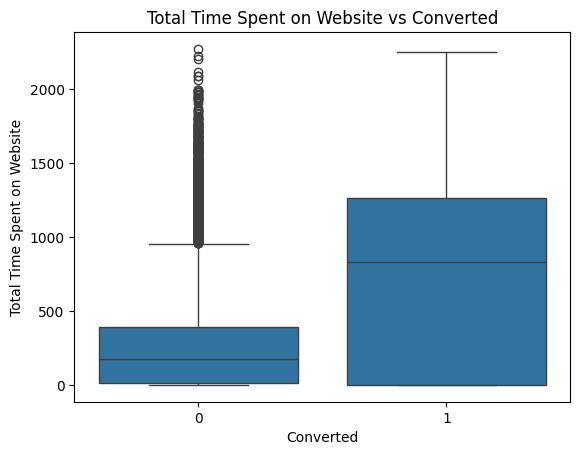

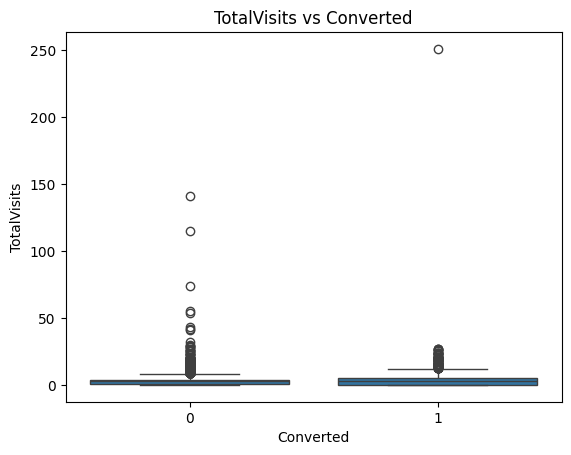

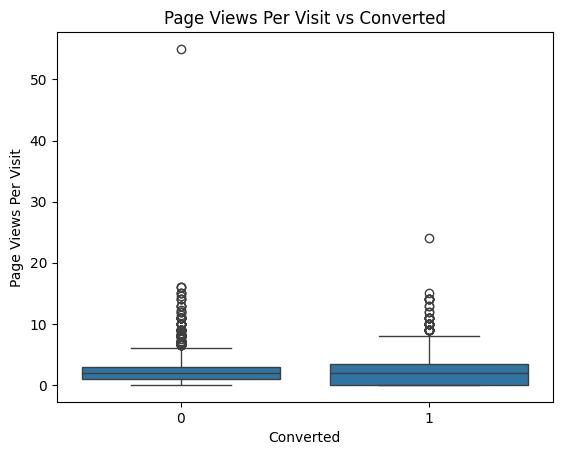

       Total Time Spent on Website  TotalVisits  Page Views Per Visit
count                  9074.000000  9074.000000           9074.000000
mean                    482.887481     3.456028              2.370151
std                     545.256560     4.858802              2.160871
min                       0.000000     0.000000              0.000000
25%                      11.000000     1.000000              1.000000
50%                     246.000000     3.000000              2.000000
75%                     922.750000     5.000000              3.200000
max                    2272.000000   251.000000             55.000000
           Total Time Spent on Website  TotalVisits  Page Views Per Visit
Converted                                                                
0                                178.0          3.0                   2.0
1                                829.0          3.0                   2.0


In [111]:
#Numerical columns EDA

num_cols = ['Total Time Spent on Website', 'TotalVisits', 'Page Views Per Visit']

for col in num_cols:
    sns.boxplot(data=lead, x='Converted', y=col)
    plt.title(f'{col} vs Converted')
    plt.show()



print(lead[num_cols].describe())


print(lead.groupby('Converted')[num_cols].median())

# **Insight**

**Total Time Spent on Website:** Converted leads spend substantially more time on the website — the strongest numeric predictor. However, the relationship isn't perfect: some high-time visitors don't convert and some converters spend little time, which is why a multi-feature model is needed rather than a single time threshold.

**TotalVisits:** Number of visits is a weak predictor — both converted and
non-converted leads have a median of ~3 visits, and the correlation with conversion is near zero (0.03). Zero-visit leads actually convert slightly higher (41%) than repeat visitors (37%). Unlike time-on-site, visit frequency does not indicate intent. Note: extreme outliers (max 251 visits) will be capped during preprocessing.


**Page Views Per Visit:** Weak predictor — converted and non-converted
leads both have a median of ~2 page views per visit. Like TotalVisits, it reflects browsing volume rather than genuine intent. Extreme outliers (max 55) will be capped during preprocessing.

In [112]:
# --- Step 1: Fix data-quality issues found during EDA ---

# 1a. Merge casing duplicate
lead['Lead Source'] = lead['Lead Source'].replace('google', 'Google')

# 1b. Group rare levels (< 50 leads) into 'Others' to avoid noisy dummy columns
for col in ['Lead Source', 'Last Activity']:
    counts = lead[col].value_counts()
    rare = counts[counts < 50].index
    lead[col] = lead[col].replace(rare, 'Others')

# 1c. Drop Last Notable Activity (redundant with Last Activity -> multicollinearity)
lead = lead.drop(columns=['Last Notable Activity'])

# Verify
print(lead['Lead Source'].value_counts())
print()
print(lead['Last Activity'].value_counts())
print()
print('Shape:', lead.shape)



Lead Source
Google              2873
Direct Traffic      2543
Olark Chat          1753
Organic Search      1154
Reference            443
Welingak Website     129
Referral Sites       125
Others                54
Name: count, dtype: int64

Last Activity
Email Opened                 3432
SMS Sent                     2716
Olark Chat Conversation       972
Page Visited on Website       640
Converted to Lead             428
Email Bounced                 312
Email Link Clicked            267
Form Submitted on Website     116
Unreachable                    90
Unsubscribed                   59
Others                         42
Name: count, dtype: int64

Shape: (9074, 13)


### Step 1: Fixing data-quality issues identified during EDA

Based on the EDA findings, three corrections are applied before encoding:

1. **Merge casing duplicate:** 'google' (lowercase, 5 rows) is the same source as 'Google' and is merged into it — a data-entry inconsistency.

2. **Group rare levels into 'Others':** Both 'Lead Source' and 'Last Activity' have a long tail of levels with very few rows (e.g. 'blog', 'testone', 'Email Marked Spam', each with 1-6 rows). Creating dummy variables for these would add many noisy columns, several representing just a single lead. All levels with fewer than 50 rows are therefore grouped into an 'Others' category.

3. **Drop 'Last Notable Activity':** EDA showed this column follows almost the same pattern as 'Last Activity'. Keeping both would introduce multicollinearit(highly correlated dummy variables), so the redundant 'Last Notable Activity' is dropped.

In [113]:
# --- Step 2: Outlier treatment (cap at 99th percentile) ---
for col in ['TotalVisits', 'Page Views Per Visit']:
    cap = lead[col].quantile(0.99)
    lead[col] = np.where(lead[col] > cap, cap, lead[col])

# Verify the new maximums
print(lead[['TotalVisits', 'Page Views Per Visit']].describe())

       TotalVisits  Page Views Per Visit
count  9074.000000           9074.000000
mean      3.343178              2.341241
std       3.252302              1.984635
min       0.000000              0.000000
25%       1.000000              1.000000
50%       3.000000              2.000000
75%       5.000000              3.200000
max      17.000000              9.000000


### Step 2: Outlier treatment

'TotalVisits' (max 251) and 'Page Views Per Visit' (max 55) contain extreme outliers far beyond their 99th percentiles (17 and 9 respectively). Rather than deleting these rows (which would lose approx-80 leads and their information), the values are **capped at the 99th percentile** (winsorizing). This removes the distorting effect of extreme values on the regression coefficients and on feature scaling, while retaining every row. 'Total Time Spent on Website' was left unchanged as its maximum (~2272s ≈ 38 min) is
plausible behaviour, not a data error.

In [114]:
# --- Step 3: Derive a new metric — Avg Time Per Visit ---
# Engagement depth: how long the lead spends per visit (combines time & visit count)

lead['Avg Time Per Visit'] = lead['Total Time Spent on Website'] / lead['TotalVisits'].replace(0, np.nan)
lead['Avg Time Per Visit'] = lead['Avg Time Per Visit'].fillna(0)

In [115]:
# Check predictive signal of the new metric
print('Avg Time Per Visit vs Converted:', lead['Avg Time Per Visit'].corr(lead['Converted']).round(3))
print('\nTotalVisits vs Converted:', lead['TotalVisits'].corr(lead['Converted']).round(3))

# Conversion rate across engagement bands
lead['eng_band'] = pd.qcut(lead['Avg Time Per Visit'], 4, labels=['Low','Med','High','Very High'])
print(lead.groupby('eng_band', observed=True)['Converted'].agg(['mean','count']).round(3))

Avg Time Per Visit vs Converted: 0.219

TotalVisits vs Converted: 0.049
            mean  count
eng_band               
Low        0.400   2272
Med        0.161   2265
High       0.350   2268
Very High  0.603   2269


In [116]:
lead = lead.drop(columns=['eng_band'])

### Step 3: Deriving a new metric — Avg Time Per Visit

EDA revealed that *total* time on the website is a strong predictor while the *number of visits* is not. To capture **engagement depth**, a new feature is derived:

**Avg Time Per Visit = Total Time Spent on Website / TotalVisits**

This measures how long a lead spends per individual visit. A divide-by-zero safeguard is applied for leads with 0 visits (result set to 0). The new metric correlates with conversion at 0.22 — stronger than visit count alone — and leads in the highest engagement band convert at ~60% vs ~16-40% for lower bands, confirming it carries genuine predictive signal worth including in the model.

In [117]:
# --- Step 4: Encode binary (Yes/No) columns to 1/0 ---
binary_cols = ['Do Not Email', 'A free copy of Mastering The Interview']
for col in binary_cols:
    lead[col] = lead[col].map({'Yes': 1, 'No': 0})

# Verify
print(lead[binary_cols].head())
print(lead[binary_cols].sum())   # count of 1s in each

   Do Not Email  A free copy of Mastering The Interview
0             0                                       0
1             0                                       0
2             0                                       1
3             0                                       0
4             0                                       0
Do Not Email                               716
A free copy of Mastering The Interview    2888
dtype: int64


### Step 4: Encoding binary variables

'Do Not Email' and 'A free copy of Mastering The Interview' are binary (Yes/No) columns. Each is mapped to 1/0 (Yes -> 1, No -> 0). A single 0/1 column fully represents a binary variable, so dummy encoding is unnecessary here — that is reserved for the multi-level categorical variables in the next step.

In [118]:
# --- Step 5: Create dummy variables for multi-level categoricals ---
cat_cols = ['Lead Origin', 'Lead Source', 'Last Activity',
            'Specialization', 'What is your current occupation']

# One-hot encode with drop_first to avoid the dummy variable trap
dummies = pd.get_dummies(lead[cat_cols], drop_first=True)

# Attach the dummies and remove the original text columns
lead = pd.concat([lead.drop(columns=cat_cols), dummies], axis=1)

print('Shape after dummies:', lead.shape)

Shape after dummies: (9074, 53)


### Step 5: Creating dummy variables

The five multi-level categorical variables (Lead Origin, Lead Source, Last Activity, Specialization, Occupation) are one-hot encoded using *pd.get_dummies.*

*drop_first=True* is used so that a column with k levels produces k−1 dummies. This avoids the **dummy variable trap** — perfect multicollinearity that arises when all k levels are kept, since the last level is fully determined by the others.

The dropped level serves as the reference category for interpreting coefficients.

This expands the dataset from 14 to 53 columns (44 dummy variables replacing the 5 original categorical columns).

In [119]:
# --- Step 6:
# Drop identifier columns and Keep Lead Number aside to map scores back to leads at the end

lead_numbers = lead['Lead Number'].copy()


lead = lead.drop(columns=['Prospect ID', 'Lead Number'])
print('Shape after dropping IDs:', lead.shape)





Shape after dropping IDs: (9074, 51)


### Step 6: Dropping identifier columns

'Prospect ID' and 'Lead Number' are unique identifiers with no predictive value — a lead's ID does not influence whether it converts. They are dropped before modelling.

Lead Number can be re-attached at the end via the dataframe index to map the final lead scores back to individual leads.

In [120]:
# --- Step 7: Train-test split ---
from sklearn.model_selection import train_test_split

# X = all predictor features, y = target
X = lead.drop(columns=['Converted'])
y = lead['Converted']

# 70:30 split, stratified on y to preserve the conversion ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=100, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Train conversion rate:', round(y_train.mean(), 3))
print('Test conversion rate:', round(y_test.mean(), 3))

X_train: (6351, 50) | X_test: (2723, 50)
Train conversion rate: 0.379
Test conversion rate: 0.379


### Step 7: Train-test split

The data is split into features (X = all columns except 'Converted') and target
(y = 'Converted'), then divided 70:30 into training and test sets. The model is built only on the training set and evaluated on the unseen test set, giving an honest measure of real-world performance.

- *random_state=100* ensures the split is reproducible.
- *stratify=y* preserves the ~38% conversion ratio in both sets, preventing class imbalance between them.

In [121]:
# --- Step 8: Scale numeric features ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['TotalVisits', 'Total Time Spent on Website',
            'Page Views Per Visit', 'Avg Time Per Visit']

# Fit the scaler on TRAINING data only, then transform train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform the test data using the SAME scaler (no re-fitting)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train[num_cols].describe().round(2))

       TotalVisits  Total Time Spent on Website  Page Views Per Visit  \
count      6351.00                      6351.00               6351.00   
mean         -0.00                         0.00                 -0.00   
std           1.00                         1.00                  1.00   
min          -1.03                        -0.88                 -1.18   
25%          -0.72                        -0.87                 -0.67   
50%          -0.10                        -0.44                 -0.17   
75%           0.52                         0.81                  0.33   
max           4.23                         3.26                  3.36   

       Avg Time Per Visit  
count             6351.00  
mean                 0.00  
std                  1.00  
min                 -0.71  
25%                 -0.70  
50%                 -0.40  
75%                  0.29  
max                  8.28  


### Step 8: Feature scaling

The numeric features have very different ranges (e.g. Total Time Spent: 0–2272 vs Page Views Per Visit: 0–9). They are standardized using StandardScaler (mean 0, std 1) so their model coefficients become directly comparable.

**Important:** the scaler is *fit on the training set only* (fit_transform) and then *applied* to the test set (transform) without re-fitting. This prevents data leakage — the test set must remain genuinely unseen, including its summary statistics.

Dummy and binary variables are already 0/1 and are not scaled.

In [122]:
# --- Model Building Stage 1: RFE feature selection ---
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

logreg = LogisticRegression(max_iter=1000)
rfe = RFE(logreg, n_features_to_select=15)
rfe.fit(X_train, y_train)

# The 15 features RFE selected
selected_cols = X_train.columns[rfe.support_].tolist()
print(selected_cols)

['Do Not Email', 'Total Time Spent on Website', 'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form', 'Lead Source_Olark Chat', 'Lead Source_Welingak Website', 'Last Activity_Email Opened', 'Last Activity_Olark Chat Conversation', 'Last Activity_Others', 'Last Activity_SMS Sent', 'Last Activity_Unsubscribed', 'Specialization_Unknown', 'What is your current occupation_Housewife', 'What is your current occupation_Unknown', 'What is your current occupation_Working Professional']


### Model Building — Stage 1: Automated feature selection with RFE

With ~50 features, Recursive Feature Elimination (RFE) is used to select the 15 most informative ones. RFE repeatedly fits the model, ranks features by importance, and removes the weakest until 15 remain.

The selected features align strongly with the EDA findings — Total Time Spent on Website, Lead Add Form, Welingak Website, SMS Sent, Working Professional, and Do Not Email all survive. These 15 features go into Stage 2, where they are manually refined using statistical significance (p-values) and multicollinearity (VIF).

In [123]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fit a logistic regression model on the given features
def build_model(features):
    X = X_train[features].astype(float)
    X_sm = sm.add_constant(X)              # add intercept term
    model = sm.GLM(y_train, X_sm, family=sm.families.Binomial()).fit()
    return model

# Compute VIF for the given features
def check_vif(features):
    X = X_train[features].astype(float)
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

In [124]:
# selected_cols = the 15 features from RFE
model1 = build_model(selected_cols)
print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6351
Model:                            GLM   Df Residuals:                     6335
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2571.4
Date:                Fri, 19 Jun 2026   Deviance:                       5142.7
Time:                        04:46:58   Pearson chi2:                 6.70e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.4036
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

**Iteration 1:** 'Occupation_Housewife' shows coefficient ~22.9 and p-value ~1.0 -> a sign of perfect separation (only 9 such leads, all converted). It is dropped first.

In [125]:
# Drop the perfect-separation feature
selected_cols.remove('What is your current occupation_Housewife')

model2 = build_model(selected_cols)
print(model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6351
Model:                            GLM   Df Residuals:                     6336
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2576.0
Date:                Fri, 19 Jun 2026   Deviance:                       5152.0
Time:                        04:46:58   Pearson chi2:                 6.71e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4028
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [126]:
check_vif(selected_cols)

,Feature,VIF
0,Lead Origin_Landing Page Submission,2.915663
1,Specialization_Unknown,2.743216
2,Last Activity_Email Opened,2.515921
3,Lead Source_Olark Chat,2.256177
4,Last Activity_SMS Sent,2.228655
5,Last Activity_Olark Chat Conversation,1.797193
6,Lead Origin_Lead Add Form,1.723316
7,What is your current occupation_Unknown,1.626451
8,Lead Source_Welingak Website,1.384044
9,Total Time Spent on Website,1.313066


### Model Building — Stage 2: Manual refinement (p-values & VIF)

The 15 RFE features are fit using statsmodels (GLM/Binomial), which provides p-values and coefficients for inspection. Features are then removed one at a time if they are statistically insignificant (p > 0.05) or show high multicollinearity (VIF > 5), re-fitting after each removal.

**Iteration 1:** 'Occupation_Housewife' shows a coefficient of ~22.9 and p-value ~1.0 — a sign of *perfect separation* (only 9 such leads, all converted). It is dropped first.


**Iteration 1 result:** After dropping 'Occupation_Housewife', all 14 remaining
features have p-values < 0.05 (highest 0.0036) and VIF < 5 (highest 2.92). No further elimination is needed — this is the final model.

In [127]:
# Final model and feature list
final_features = selected_cols
final_model = build_model(final_features)
print(final_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6351
Model:                            GLM   Df Residuals:                     6336
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2576.0
Date:                Fri, 19 Jun 2026   Deviance:                       5152.0
Time:                        04:49:07   Pearson chi2:                 6.71e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4028
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [128]:
# Confirm all p-values are below 0.05
pvals = final_model.pvalues
print('Max p-value among features:', round(pvals.max(), 4))
print('All features significant (p < 0.05)?', (pvals < 0.05).all())

Max p-value among features: 0.0036
All features significant (p < 0.05)? True


In [129]:
#Predicted probabilities on train

from sklearn import metrics
import matplotlib.pyplot as plt

# Predicted probability of conversion for each training lead
X_train_sm = sm.add_constant(X_train[final_features].astype(float))
y_train_pred = final_model.predict(X_train_sm)

# Dataframe of actual vs predicted probability
train_results = pd.DataFrame({'Converted': y_train.values, 'Conv_Prob': y_train_pred.values})
train_results.head()

,Converted,Conv_Prob
0,0,0.030130
1,0,0.024800
2,0,0.417289
3,1,0.610887
4,0,0.147117


In [130]:
#Find optimal cutoff (test a range)

# Test cutoffs from 0.0 to 0.9 and record the three key metrics at each
cutoff_df = pd.DataFrame(columns=['cutoff', 'accuracy', 'sensitivity', 'specificity'])

for i in np.arange(0, 1, 0.1):
    predicted = (train_results['Conv_Prob'] >= i).astype(int)
    cm = metrics.confusion_matrix(train_results['Converted'], predicted)
    TN, FP, FN, TP = cm.ravel()
    cutoff_df.loc[i] = [i,
                        (TP+TN)/cm.sum(),      # accuracy
                        TP/(TP+FN),            # sensitivity
                        TN/(TN+FP)]            # specificity

print(cutoff_df)

     cutoff  accuracy  sensitivity  specificity
0.0     0.0  0.378523     1.000000     0.000000
0.1     0.1  0.625571     0.976705     0.411705
0.2     0.2  0.757046     0.910566     0.663542
0.3     0.3  0.795308     0.845258     0.764885
0.4     0.4  0.811998     0.769967     0.837598
0.5     0.5  0.816407     0.700083     0.887256
0.6     0.6  0.800346     0.598586     0.923233
0.7     0.7  0.784128     0.516223     0.947302
0.8     0.8  0.760510     0.413478     0.971877
0.9     0.9  0.714848     0.265807     0.988346


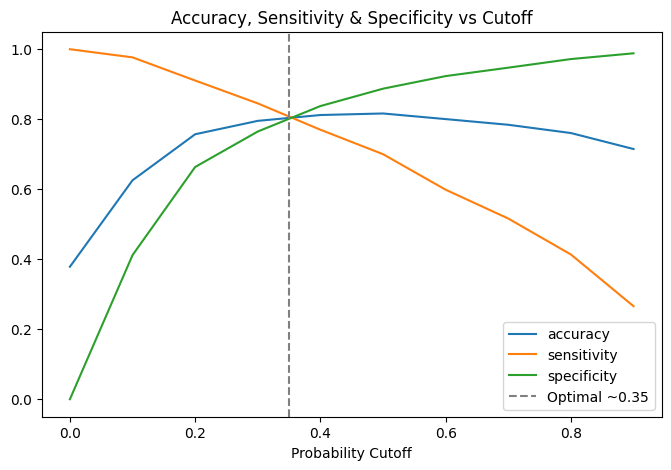

In [131]:
# Plotting the curves to check the instersection

# The optimal cutoff is where the three curves intersect
cutoff_df.plot(x='cutoff', y=['accuracy', 'sensitivity', 'specificity'], figsize=(8,5))
plt.axvline(0.35, color='gray', linestyle='--', label='Optimal ~0.35')
plt.title('Accuracy, Sensitivity & Specificity vs Cutoff')
plt.xlabel('Probability Cutoff')
plt.legend()
plt.show()

**Optimal cutoff:** The three curves intersect at approximately **0.35**, where
accuracy, sensitivity and specificity are all ~0.80 — a balanced model meeting the CEO's ~80% target.

In [132]:
# Apply cutoff to TRAIN, final train metrics

# Apply the chosen 0.35 cutoff

optimal_cutoff = 0.35
train_results['Predicted'] = (train_results['Conv_Prob'] >= optimal_cutoff).astype(int)

cm_train = metrics.confusion_matrix(train_results['Converted'], train_results['Predicted'])
TN, FP, FN, TP = cm_train.ravel()
print('TRAIN metrics @ 0.35')
print('Accuracy   :', round((TP+TN)/cm_train.sum(), 3))
print('Sensitivity:', round(TP/(TP+FN), 3))
print('Specificity:', round(TN/(TN+FP), 3))
print('Precision  :', round(TP/(TP+FP), 3))

TRAIN metrics @ 0.35
Accuracy   : 0.806
Sensitivity: 0.806
Specificity: 0.806
Precision  : 0.717


In [134]:
# Evaluate on TEST set
# Apply the SAME model and cutoff to the unseen test set
X_test_sm = sm.add_constant(X_test[final_features].astype(float), has_constant='add')
y_test_pred = final_model.predict(X_test_sm)

test_results = pd.DataFrame({'Converted': y_test.values, 'Conv_Prob': y_test_pred.values})
test_results['Predicted'] = (test_results['Conv_Prob'] >= optimal_cutoff).astype(int)

cm_test = metrics.confusion_matrix(test_results['Converted'], test_results['Predicted'])
TN, FP, FN, TP = cm_test.ravel()
print('TEST metrics at 0.35')
print('Accuracy   :', round((TP+TN)/cm_test.sum(), 3))
print('Sensitivity:', round(TP/(TP+FN), 3))
print('Specificity:', round(TN/(TN+FP), 3))
print('Precision  :', round(TP/(TP+FP), 3))
print('ROC-AUC    :', round(metrics.roc_auc_score(test_results['Converted'], test_results['Conv_Prob']), 3))

TEST metrics at 0.35
Accuracy   : 0.806
Sensitivity: 0.801
Specificity: 0.809
Precision  : 0.719
ROC-AUC    : 0.894


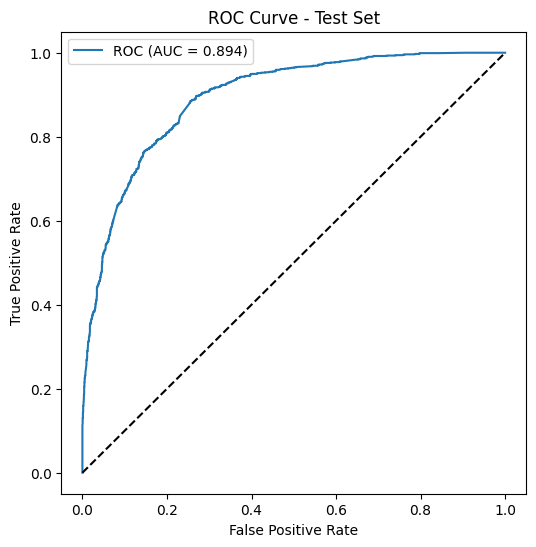

In [135]:
# ROC curve

fpr, tpr, _ = metrics.roc_curve(test_results['Converted'], test_results['Conv_Prob'])
auc = metrics.roc_auc_score(test_results['Converted'], test_results['Conv_Prob'])
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set'); plt.legend()
plt.show()

**Generalization:** Test-set metrics (accuracy 0.81, sensitivity 0.80, specificity 0.81, AUC 0.89) match the training set closely — the model is not overfitting and reliably identifies ~80% of converting leads, meeting the business target.

## Lead Scoring

The objective of this assignment is to assign each lead a score (0-100) where a higher score indicates a higher chance of conversion. Since the model already outputs a conversion *probability* for each lead, the lead score is simply that probability * 100.

In [136]:
# Lead Score = predicted conversion probability × 100  (0–100 scale)
test_results['Lead_Score'] = (test_results['Conv_Prob'] * 100).round().astype(int)

# Sort so the hottest leads appear first
test_results = test_results.sort_values('Lead_Score', ascending=False)
test_results[['Converted', 'Conv_Prob', 'Lead_Score']].head(10)

,Converted,Conv_Prob,Lead_Score
586,1,0.997245,100
2584,1,0.996763,100
2601,1,0.996882,100
593,1,0.995346,100
620,1,0.996882,100
652,1,0.996882,100
729,1,0.995346,100
841,1,0.997001,100
860,1,0.997677,100
894,1,0.997867,100


### Validating the Lead Score

A useful lead score must rank leads correctly — higher scores should convert more often. We group leads into score bands and check the actual conversion rate in each.

In [137]:
# Check actual conversion rate within each score band
test_results['Score_Band'] = pd.cut(
    test_results['Lead_Score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '20-40', '40-60', '60-80', '80-100']
)
print(test_results.groupby('Score_Band', observed=True)['Converted'].agg(['mean', 'count']).round(3))

             mean  count
Score_Band              
0-20        0.066   1213
20-40       0.346    456
40-60       0.573    335
60-80       0.749    251
80-100      0.888    465


**Result:** The conversion rate rises cleanly with the score band:

| Lead Score | Conversion Rate |
|------------|-----------------|
| 0-20       | ~7%             |
| 20-40      | ~35%            |
| 40-60      | ~57%            |
| 60-80      | ~75%            |
| 80-100     | ~89%            |

The monotonic increase confirms the score reliably prioritises leads. Leads scoring 80-100 convert at ~89% versus only ~7% for those scoring 0-20. This gives X Education exactly the tool it needs: sort leads by score and focus sales effort on the highest scorers first.

## Conclusion

A logistic regression model was built to predict lead conversion for X Education. After thorough cleaning, EDA, and preprocessing, the final 14-feature model achieves ~80% accuracy, ~80% sensitivity, and an ROC-AUC of ~0.89 on the unseen test set, meeting the CEO's target conversion rate of ~80%. Each lead is assigned a 0–100 score that reliably ranks conversion likelihood, enabling the sales team to prioritise the most promising leads.